In [2]:
# Cell 1: Tiền xử lý dữ liệu và Ép Index cho Keras (Phiên bản đồng bộ File PKL)
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pickle

print("BƯỚC 1: LOAD DỮ LIỆU ĐÃ PRE-PROCESS CỦA BẢO")
print("=" * 60)

# 1. Đọc thẳng file dữ liệu Train/Test
train_df = pd.read_csv('../../Bảo/models/train_set.csv')
test_df = pd.read_csv('../../Bảo/models/test_set.csv')

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")

# 2. Đọc file mapping (.pkl) để lấy chính xác kích thước Không gian Nhúng (Embedding)
with open('../../Bảo/models/user_to_index.pkl', 'rb') as f:
    user_to_index = pickle.load(f)
with open('../../Bảo/models/item_to_index.pkl', 'rb') as f:
    item_to_index = pickle.load(f)

num_users = len(user_to_index)
num_artists = len(item_to_index)

print(f"\nTổng số User trong từ điển: {num_users}")
print(f"Tổng số Artist trong từ điển: {num_artists}")

# 3. Trích xuất mảng dữ liệu đưa vào Keras (Bảo đã làm sẵn cột Index, chỉ việc dùng)
X_train_user = train_df['user_index'].values
X_train_artist = train_df['item_index'].values
y_train = train_df['rating'].values

X_test_user = test_df['user_index'].values
X_test_artist = test_df['item_index'].values
y_test = test_df['rating'].values

print("Hoàn tất chuẩn bị dữ liệu cho Lớp Nhúng (Embedding)!")
print("=" * 60)

BƯỚC 1: LOAD DỮ LIỆU ĐÃ PRE-PROCESS CỦA BẢO
Kích thước tập Train: (74267, 3)
Kích thước tập Test: (18567, 3)

Tổng số User trong từ điển: 1892
Tổng số Artist trong từ điển: 17632
Hoàn tất chuẩn bị dữ liệu cho Lớp Nhúng (Embedding)!


In [3]:
# Cell 2: Lắp ráp mạng Keras Matrix Factorization
print("BƯỚC 2: XÂY DỰNG KHUNG XƯƠNG MATRIX FACTORIZATION")
print("=" * 60)

LATENT_DIM = 32  # Đồng bộ tham số với cấu hình cơ sở của Bảo

# 1. Các cổng đầu vào (Input)
user_input = Input(shape=(1,), name='user_input')
artist_input = Input(shape=(1,), name='artist_input')

# 2. Lớp Nhúng (Embedding) - Biến ID thành Vector 32 chiều
user_embedding = Embedding(input_dim=num_users, output_dim=LATENT_DIM, name='user_embedding')(user_input)
user_vec = Flatten(name='flatten_user')(user_embedding)

artist_embedding = Embedding(input_dim=num_artists, output_dim=LATENT_DIM, name='artist_embedding')(artist_input)
artist_vec = Flatten(name='flatten_artist')(artist_embedding)

# 3. Tích vô hướng (Dot Product)
dot_product = Dot(axes=1, name='dot_product')([user_vec, artist_vec])

# 4. Biên dịch mô hình
model = Model(inputs=[user_input, artist_input], outputs=dot_product)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Hiển thị bản thiết kế kiến trúc
model.summary()
print("=" * 60)

BƯỚC 2: XÂY DỰNG KHUNG XƯƠNG MATRIX FACTORIZATION


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ artist_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │     60,544 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ artist_embedding    │ (None, 1, 32)     │    564,224 │ artist_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_user        │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_artist      │ (None, 32)        │          0 │ artist_embedding… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1)         │          0 │ flatten_user[0][… │
│                     │                   │            │ flatten_artist[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 624,768 (2.38 MB)

 Trainable params: 624,768 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

BƯỚC 3: HUẤN LUYỆN VÀ ĐÁNH GIÁ (EPOCHS=5)
Epoch 1/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 10.9883 - val_loss: 10.8851
Epoch 2/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 10.2309 - val_loss: 8.9079
Epoch 3/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0309 - val_loss: 5.5867
Epoch 4/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.3342 - val_loss: 3.8975
Epoch 5/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.9029 - val_loss: 3.0761


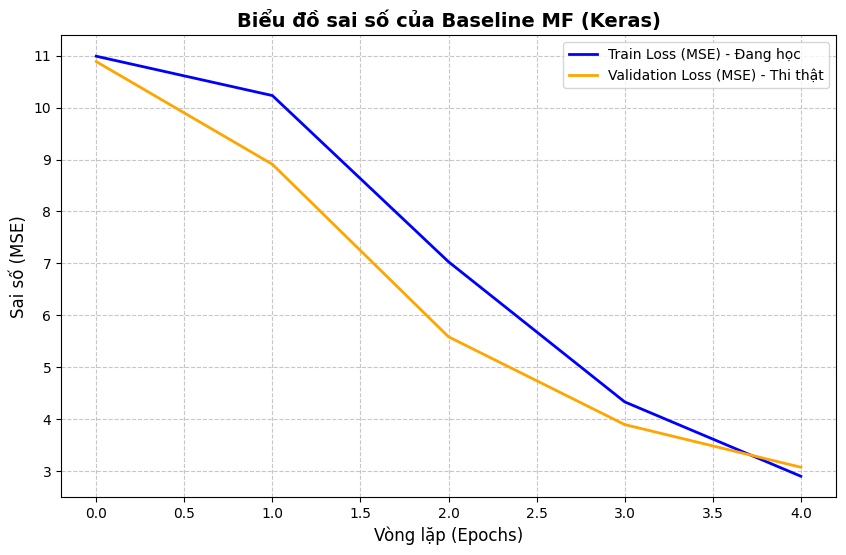

In [4]:
# Cell 3: Huấn luyện và theo dõi Validation Loss
print("BƯỚC 3: HUẤN LUYỆN VÀ ĐÁNH GIÁ (EPOCHS=5)")
print("=" * 60)

# Tiến hành huấn luyện (Dùng X_test làm giám khảo)
history = model.fit(
    x=[X_train_user, X_train_artist],
    y=y_train,
    validation_data=([X_test_user, X_test_artist], y_test),
    epochs=5,           # Chỉ chạy thử 5 vòng trên Local
    batch_size=256,     # Xử lý 256 mẫu một lúc
    verbose=1           # Hiển thị thanh tiến trình
)

# Vẽ biểu đồ trực quan xem có bị học vẹt không
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss (MSE) - Đang học', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE) - Thi thật', color='orange', linewidth=2)
plt.title('Biểu đồ sai số của Baseline MF (Keras)', fontsize=14, fontweight='bold')
plt.xlabel('Vòng lặp (Epochs)', fontsize=12)
plt.ylabel('Sai số (MSE)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [5]:
# Cell 4: DỰ ĐOÁN TOP 10 (SỬ DỤNG NUMPY ĐỂ VƯỢT LỖI TENSORFLOW CPU)
import time
import numpy as np
import pandas as pd

print("BƯỚC 4: DỰ ĐOÁN TOP 10 NGHỆ SĨ CHO USER")
print("=" * 60)

# Tạo từ điển dịch ngược để in ra tên thật (ID gốc)
index_to_item = {index: item_id for item_id, index in item_to_index.items()}

# TRÍCH XUẤT TRỌNG SỐ TỪ MÔ HÌNH SAU KHI TRAIN
# Việc này hoàn toàn không làm thay đổi chất lượng mô hình đã Train ở Cell 3
user_weights = model.get_layer('user_embedding').get_weights()[0]   
artist_weights = model.get_layer('artist_embedding').get_weights()[0] 

def get_recommendations_safe(user_id_that, top_n=10):
    if user_id_that not in user_to_index:
        return "User không tồn tại trong hệ thống!"

    user_idx = user_to_index[user_id_that]
    
    # RÚT ĐÚNG 1 VECTOR của User hiện tại (Shape: 32)
    target_user_vector = user_weights[user_idx] 
    
    # Dùng NumPy nhân ma trận: (17632, 32) x (32,) -> Ra chính xác 17632 điểm số
    predicted_ratings = np.dot(artist_weights, target_user_vector) 
    
    all_artist_indices = np.array(list(item_to_index.values()))
    
    # Gom kết quả lại vào bảng Pandas và sắp xếp
    results = pd.DataFrame({
        'artist_index': all_artist_indices,
        'predicted_rating': predicted_ratings
    })

    top_results = results.sort_values(by='predicted_rating', ascending=False).head(top_n)
    
    # Dịch ngược Index -> ID thật
    top_results['artistID_thật'] = top_results['artist_index'].map(index_to_item)

    return top_results[['artistID_thật', 'predicted_rating']]

# Test thử ngay với User đầu tiên
sample_user = list(user_to_index.keys())[0]

print(f"Đang tính toán an toàn cho User ID: {sample_user}...")
top_10 = get_recommendations_safe(sample_user, top_n=10)

print("\n--- KẾT QUẢ TOP 10 GỢI Ý ---")
print(top_10.to_string(index=False))
print("=" * 60)

BƯỚC 4: DỰ ĐOÁN TOP 10 NGHỆ SĨ CHO USER
Đang tính toán an toàn cho User ID: 0...

--- KẾT QUẢ TOP 10 GỢI Ý ---
 artistID_thật  predicted_rating
            21          4.947082
           122          4.508167
          1049          4.400903
           176          4.324527
           182          4.231085
           139          4.199305
            16          4.198432
           156          4.142697
           103          4.142633
           178          4.141273


In [6]:
# Cell 5: Đóng gói và Lưu cỗ máy Keras
print("BƯỚC 5: XUẤT XƯỞNG MÔ HÌNH")
print("=" * 60)

# Lưu thành file .keras chuẩn mới
model.save('baseline_mf.keras')

print("✅ Đã lưu mô hình thành công vào file: 'baseline_mf.keras'")
print("=" * 60)

BƯỚC 5: XUẤT XƯỞNG MÔ HÌNH
✅ Đã lưu mô hình thành công vào file: 'baseline_mf.keras'
